![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte B: Entrenamiento de Redes Neuronales -- SOLUCION

**Asignatura:** Redes Neuronales Profundas 
**Bloque:** 1 — Fundamentos de Deep Learning 

---

## Introducción

En el TP1a aprendiste a operar con tensores. Ahora vas a usar esas herramientas para algo concreto: **entrenar redes neuronales**.

En este trabajo vas a:

1. Implementar el **loop de entrenamiento** de una red de clasificación de imágenes desde cero.
2. Entender qué pasa en cada paso del ciclo: forward pass, cálculo de pérdida, backward pass y actualización de pesos.

### Dataset: FashionMNIST

Vamos a trabajar con el dataset **FashionMNIST**, un conjunto estándar de 70.000 imágenes en escala de grises de 28×28 píxeles de prendas de ropa, divididas en 10 categorías:

| Etiqueta | Clase |
|:-:|---|
| 0 | T-shirt/top |
| 1 | Pantalón |
| 2 | Pulóver |
| 3 | Vestido |
| 4 | Abrigo |
| 5 | Sandalia |
| 6 | Camisa |
| 7 | Zapatilla |
| 8 | Bolso |
| 9 | Bota |

---

## Instrucciones generales

- Las celdas de **setup** ya están escritas — ejecutálas sin modificar.
- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto marcadas con .

---
## Ejercicios


In [20]:
# Imports
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils import data
import matplotlib.pyplot as plt

print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0


### Ejercicio 1 — Implementar `load_data_fashion_mnist()`

**Objetivo:** Descargar el dataset FashionMNIST y construir los iteradores de datos.

**Enunciado:**

1. Definí la transformación con `transforms.ToTensor()`.
2. Descargá el dataset con `torchvision.datasets.FashionMNIST()` con `download=True`.
3. Creá los DataLoaders con `data.DataLoader()`, con `shuffle=True` para entrenamiento.

> **Pistas:**
> - Usá `transforms.ToTensor()` para la transformación.
> - Usá `torchvision.datasets.FashionMNIST()` con `download=True`.
> - Creá los DataLoaders con `data.DataLoader()`, con `shuffle=True` para entrenamiento.


In [21]:
def load_data_fashion_mnist(batch_size):
    """
    Descarga y prepara el dataset FashionMNIST.

    Parámetros:
    batch_size (int): cantidad de imágenes por lote

    Retorna:
    train_iter: DataLoader de entrenamiento (60.000 imágenes)
    test_iter: DataLoader de prueba (10.000 imágenes)
    """
    # Transformación: convertir las imágenes PIL a tensores de PyTorch
    trans = transforms.ToTensor()

    # Descargar el dataset (train y test)
    mnist_train = torchvision.datasets.FashionMNIST(
        root='./data', train=True, transform=trans, download=True
    )
    mnist_test = torchvision.datasets.FashionMNIST(
        root='./data', train=False, transform=trans, download=True
    )

    # Crear DataLoaders: iteradores que entregan lotes del tamaño indicado
    train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)
    test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False)

    return train_iter, test_iter


**Pregunta de análisis:**

¿Por qué se usa `shuffle=True` en el DataLoader de entrenamiento pero no en el de prueba?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Durante el entrenamiento, si los lotes siempre llegan en el mismo orden, el modelo podría aprender a depender del orden de los datos en lugar de aprender patrones generales. `shuffle=True` mezcla el dataset antes de cada época, asegurando que cada lote sea una muestra aleatoria y que los gradientes calculados sean representativos del dataset completo. En prueba, el orden no importa porque solo estamos midiendo el accuracy sin actualizar pesos.

### Ejercicio 2 — Definir el modelo, la pérdida y el optimizador

**Objetivo:** Construir los componentes principales del sistema de entrenamiento.

**Enunciado:**

1. Creá una red `nn.Sequential` con `nn.Flatten()` y una capa `nn.Linear(784, 10)`.
2. Inicializá los pesos de la capa lineal con distribución normal de `std=0.01`.
3. Definí la función de pérdida `nn.CrossEntropyLoss(reduction='none')`.
4. Definí el optimizador `torch.optim.SGD` con `lr=0.1`.

> **Pistas:**
> - `nn.Flatten()` convierte las imágenes de forma `(1, 28, 28)` en vectores de `784` elementos.
> - `nn.Linear(784, 10)` produce 10 puntuaciones (una por clase) a partir de esos 784 valores.
> - Para inicializar los pesos, definí una función `init_weights(m)` y aplicala con `net.apply()`.
> - `CrossEntropyLoss` aplica Softmax internamente, **no** hace falta agregarlo al modelo.


In [22]:
# Modelo base: red de una capa (regresion softmax)
# Este modelo es Sequential con:
# 1. Flatten: convierte las imagenes de (28x28) en vectores de 784 elementos
# 2. Linear(784, 10): una capa densa que produce 10 puntuaciones (una por clase)

net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

# Inicializamos los pesos con valores pequenos de distribucion normal
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

# Funcion de perdida CrossEntropyLoss y optimizador SGD con lr=0.1
# La funcion de perdida (CrossEntropyLoss) aplica Softmax internamente.

loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1) #Descenso de Gradiente Estocástico

print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


**Pregunta de análisis:**

¿Por qué se usa `CrossEntropyLoss` con `reduction='none'` en lugar de `reduction='mean'`?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Con `reduction='none'`, la función devuelve un valor de pérdida por cada ejemplo del lote (un vector de tamaño `batch_size`). Esto nos da flexibilidad: podemos promediar con `.mean()` para el backward pass, pero también podemos acumular la suma total con `.sum()` para calcular métricas precisas sobre todo el dataset. Si usáramos `reduction='mean'` directamente, perderíamos el control sobre la acumulación y el promedio entre lotes de distinto tamaño podría ser incorrecto.

---
## El ciclo de entrenamiento

Todo el entrenamiento de una red neuronal en PyTorch sigue siempre el mismo patrón de cuatro pasos, que se repite para cada lote de datos:

```
1. FORWARD PASS: pasar las entradas por el modelo → obtener predicciones
2. LOSS: comparar predicciones con etiquetas reales → calcular el error
3. BACKWARD PASS: propagar el error hacia atrás → calcular gradientes
4. UPDATE: usar los gradientes para ajustar los pesos
```

Este ciclo se repite para todos los lotes del dataset. Recorrer *todo* el dataset una vez se llama **época**.


### Ejercicio 3 — Implementar `train_epoch()`

**Objetivo:** Implementar el entrenamiento de una época completa.

**Enunciado:**

Tenés que completar la función `train_epoch()`, que recibe el modelo, los datos de entrenamiento, la función de pérdida y el optimizador, y debe:

1. Iterar sobre todos los lotes del DataLoader (`train_iter`). Cada iteración devuelve un lote `(X, y)` donde:
- `X`: tensor de imágenes del lote — forma `(batch_size, 1, 28, 28)`
- `y`: tensor de etiquetas del lote — forma `(batch_size,)`
2. Para cada lote, seguir los **4 pasos del ciclo de entrenamiento**:
- **Forward:** `y_hat = net(X)` → predicciones del modelo
- **Loss:** `l = loss(y_hat, y)` → calcular la pérdida
- **Paso previo al backward:** limpiar los gradientes del paso anterior con `updater.zero_grad()`
- **Backward:** `l.mean().backward()` → calcular los gradientes
- **Update:** `updater.step()` → actualizar los pesos
3. Acumular la pérdida total y los aciertos para calcular las métricas de la época.
4. Retornar la pérdida promedio y el accuracy de entrenamiento.

> **Pistas:**
> - Llamá a `updater.zero_grad()` **antes** de hacer `.backward()` para borrar los gradientes del lote anterior. Si no lo hacés, los gradientes se acumulan y el entrenamiento no funciona.
> - Una vez terminada la época, el accuracy de entrenamiento es: `total_aciertos / total_ejemplos`
> - La pérdida promedio es: `perdida_total / total_ejemplos`
> - Para calcular los aciertos usá la función `accuracy()` que vas a implementar en el Ejercicio 4.

In [23]:
def train_epoch(net, train_iter, loss, updater):
    """
    Entrena la red durante una sola época (un recorrido completo del dataset).
    """
    # Ponemos el modelo en modo entrenamiento.
    # Esto activa capas como Dropout y BatchNorm que se comportan diferente
    # en entrenamiento vs. evaluación. Aunque nuestro modelo no las tiene,
    # es buena práctica llamar a .train() siempre al inicio del loop.
    net.train()

    # Acumuladores para calcular las métricas al final de la época
    perdida_total = 0.0 # suma de todas las pérdidas del lote
    aciertos_total = 0.0 # suma de predicciones correctas
    n_total = 0 # total de ejemplos procesados

    for X, y in train_iter:
        # ── Paso 1: FORWARD PASS ─────────────────────────────────────────────
        # Pasamos el lote X por el modelo para obtener las predicciones.
        # y_hat tiene forma (batch_size, 10): una puntuación por clase.
        y_hat = net(X)

        # ── Paso 2: CALCULAR LA PÉRDIDA ──────────────────────────────────────
        # CrossEntropyLoss compara y_hat (puntuaciones) con y (etiquetas reales).
        # Con reduction='none', devuelve un valor de pérdida por ejemplo del lote.
        l = loss(y_hat, y)

        # ── Paso 3: LIMPIAR GRADIENTES ───────────────────────────────────────
        # PyTorch ACUMULA los gradientes por defecto.
        # Si no los limpiamos antes del backward, los gradientes del lote
        # anterior se suman a los del lote actual → pesos incorrectos.
        updater.zero_grad()

        # ── Paso 4: BACKWARD PASS ────────────────────────────────────────────
        # .mean() convierte el vector de pérdidas en un escalar.
        # .backward() calcula los gradientes de todos los parámetros del modelo
        # respecto a ese escalar.
        l.mean().backward()

        # ── Paso 5: ACTUALIZAR PESOS ─────────────────────────────────────────
        # El optimizador usa los gradientes calculados en el paso anterior
        # para ajustar todos los pesos del modelo.
        updater.step()

        # ── Acumular métricas ─────────────────────────────────────────────────
        perdida_total += l.sum().item() # item() extrae el escalar del tensor
        aciertos_total += accuracy(y_hat, y)
        n_total += y.numel() # cantidad de ejemplos en este lote

        # Retornamos la pérdida PROMEDIO (no la suma)
        # y el accuracy (proporción de predicciones correctas)
    return perdida_total / n_total, aciertos_total / n_total

**Pregunta de análisis:**

¿Por qué es necesario llamar a `updater.zero_grad()` antes de cada `backward()`? ¿Qué pasaría si no lo hiciéramos?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

PyTorch acumula los gradientes: cada vez que se llama a `.backward()`, los nuevos gradientes se **suman** a los que ya existen en `.grad`. Sin `zero_grad()`, los gradientes del lote 1 quedarían en la memoria, y al procesar el lote 2 se sumarían sobre ellos. El resultado sería que el optimizador actualizaría los pesos usando la suma de gradientes de múltiples lotes → los pesos se moverían de forma incorrecta, y el modelo no convergería.

Esta acumulación es útil en casos específicos (por ejemplo, cuando la GPU no tiene suficiente memoria para procesar un lote grande y se divide en sub-lotes), pero en el caso general hay que limpiar los gradientes antes de cada paso.

### Ejercicio 4 — Implementar `accuracy()`

**Objetivo:** Implementar la función auxiliar que cuenta cuántas predicciones fueron correctas.

**Enunciado:**

1. Si `y_hat` tiene más de una columna (es decir, contiene puntuaciones por clase), usá `argmax` sobre el eje de las columnas para obtener la clase predicha.
2. Compará las predicciones con las etiquetas reales y sumá los aciertos.

> **Pistas:**
> - La salida del modelo tiene forma `(batch_size, 10)`: una puntuación por clase. `argmax(axis=1)` da la clase con mayor puntuación para cada imagen.
> - Antes de comparar, convertí `y_hat` al mismo tipo de dato que `y` con `.type(y.dtype)`.


In [24]:
def accuracy(y_hat, y):
    """
    Cuenta las predicciones correctas.

    Parámetros:
    y_hat: tensor de predicciones — si tiene más de una columna,
           se toma la clase con mayor puntuación (argmax).
    y: tensor de etiquetas reales (enteros)

    Retorna:
    float: cantidad de predicciones correctas
    """
    # Si y_hat tiene más de una columna, tomamos la clase predicha (argmax)
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)

    # Comparamos predicciones con etiquetas y contamos aciertos
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())


**Pregunta de análisis:**

¿Qué devuelve `y_hat.argmax(axis=1)` cuando `y_hat` tiene forma `(batch_size, 10)`? ¿Qué representa cada valor del resultado?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

`argmax(axis=1)` recorre cada fila (cada imagen del lote) y devuelve el índice de la columna con el valor máximo. El resultado es un vector de forma `(batch_size,)` donde cada elemento es un entero entre 0 y 9. Ese entero es la clase que el modelo predijo con mayor confianza para esa imagen. Por ejemplo, si la fila 0 tiene su valor máximo en la columna 5, el modelo predijo "Sandalia" para la primera imagen del lote.

### Ejercicio 5 — Implementar `test_accuracy()`

**Objetivo:** Implementar la evaluación del modelo sobre los datos de prueba.

**Enunciado:**

La función `test_accuracy()` mide qué tan bien generaliza el modelo a datos que **no vio durante el entrenamiento**. Para hacer esto:

1. Iterar sobre todos los lotes del DataLoader de prueba (`test_iter`).
2. Para cada lote, obtener las predicciones del modelo.
3. Acumular los aciertos y el total de ejemplos.
4. Retornar el accuracy total.

> **Pistas:**
> - Durante la evaluación, no necesitamos calcular gradientes. Usá el bloque `with torch.no_grad():` para desactivarlos.
> - Antes del loop, llamá a `net.eval()` para poner el modelo en modo evaluación. Esto afecta capas como Dropout (que en evaluación no apaga neuronas). En esta red no hay Dropout, pero es buena práctica hacerlo siempre.

In [25]:
def test_accuracy(net, test_iter):
    """
    Evalúa el accuracy del modelo sobre datos de prueba.
    """
    # Ponemos el modelo en modo evaluación.
    # En modo .eval(), capas como Dropout dejan de apagar neuronas
    # y BatchNorm usa estadísticas calculadas durante el entrenamiento.
    # Aunque nuestro modelo no tiene estas capas, es buena práctica.
    net.eval()  
    aciertos_total = 0.0
    n_total = 0 
    # torch.no_grad() es fundamental para la evaluación:
    # Desactiva el cálculo del grafo computacional, lo que ahorra
    # memoria y acelera el procesamiento (no construimos el grafo
    # si no vamos a necesitar calcular gradientes).
    with torch.no_grad():
        for X, y in test_iter:
            y_hat = net(X)
            aciertos_total += accuracy(y_hat, y)
            n_total += y.numel()    
    return aciertos_total / n_total

**Pregunta de análisis:**

¿Por qué desactivamos el cálculo de gradientes durante la evaluación con `torch.no_grad()`? ¿Qué recursos ahorra?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

`torch.no_grad()` desactiva el motor de autograd, que durante el entrenamiento construye el grafo computacional guardando en memoria todas las operaciones intermedias (para poder calcular los gradientes después). Este grafo puede ser significativamente más grande que los datos de entrada.

Durante la evaluación, ya sabemos que ningún `.backward()` va a ocurrir, así que todo ese trabajo es innecesario. Con `no_grad()`: (1) se ahorra la memoria del grafo, (2) se aceleran los cálculos porque no hay que registrar las operaciones. En modelos grandes esto puede reducir el uso de VRAM a la mitad.

### Ejercicio 6 — Implementar `train()`

**Objetivo:** Implementar el orquestador que ejecuta múltiples épocas de entrenamiento.

**Enunciado:**

Completá el ciclo de entrenamiento que:

1. En cada época, llama a `train_epoch()` para entrenar y a `test_accuracy()` para evaluar.
2. Acumula las métricas de cada época en una lista de tuplas `(epoch, loss, train_acc, test_acc)`.
3. Imprime un resumen de cada época.
4. Retorna la lista de métricas al final.

> **Pistas:**
> - `train_epoch()` retorna `(train_loss, train_acc)` para la época.
> - `test_accuracy()` retorna el accuracy sobre el conjunto de prueba.
> - Guardá cada resultado como una tupla `(epoch + 1, train_loss, train_acc, test_acc)` en la lista `metrics`.


In [26]:
def train(net, train_iter, test_iter, loss, num_epochs, updater):
    """
    Entrena la red durante num_epochs épocas completas.

    Parámetros:
    net: el modelo a entrenar
    train_iter: DataLoader de entrenamiento
    test_iter: DataLoader de prueba
    loss: función de pérdida
    num_epochs: cantidad de épocas de entrenamiento
    updater: optimizador ya configurado

    Retorna:
    metrics: lista de tuplas (epoch, loss, train_acc, test_acc)
    """
    metrics = []

    for epoch in range(num_epochs):
        # Entrenar una época completa
        train_loss, train_acc = train_epoch(net, train_iter, loss, updater)

        # Evaluar accuracy sobre datos de prueba
        test_acc = test_accuracy(net, test_iter)

        # Guardar métricas de esta época
        metrics.append((epoch + 1, train_loss, train_acc, test_acc))

        print(f'Época {epoch + 1}/{num_epochs}: '
              f'pérdida={train_loss:.4f}, '
              f'train_acc={train_acc:.3f}, '
              f'test_acc={test_acc:.3f}')

    return metrics


**Pregunta de análisis:**

¿Qué diferencia hay entre el accuracy de entrenamiento (`train_acc`) y el de prueba (`test_acc`)? ¿Por qué es importante medir ambos?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

`train_acc` mide qué tan bien clasifica el modelo sobre los datos que **vio** durante el entrenamiento; `test_acc` mide qué tan bien **generaliza** a datos nuevos. Un modelo que memoriza los datos de entrenamiento tendrá `train_acc` muy alto y `test_acc` bajo (*overfitting*). Medir ambos permite detectar ese problema: si la brecha entre ambas métricas es grande, el modelo aprendió ruido en vez de patrones generales.

### Ejercicio 7 — Entrenar y visualizar

**Objetivo:** Usar las funciones implementadas para entrenar efectivamente la red y analizar las curvas de entrenamiento.

**Enunciado:**

1. Cargar el dataset con `load_data_fashion_mnist(batch_size=256)`.
2. Llamar a `train()` para entrenar el modelo durante **10 épocas**.
3. Graficar las curvas usando el código provisto más abajo.

> **Cómo usar `train()`:**
> La función `train()` que implementaste en el Ejercicio 6 recibe:
> - `net`: el modelo (definido en el Ejercicio 2)
> - `train_iter`, `test_iter`: los dos DataLoaders
> - `loss`: la función de pérdida (definida en el Ejercicio 2)
> - `num_epochs`: cantidad de épocas
> - `updater`: el optimizador (definido en el Ejercicio 2)
>
> Devuelve una lista de tuplas `(epoch, loss, train_acc, test_acc)` que podés guardar en una variable.

In [27]:
# Código de graficación — ejecutar sin modificar
# Esta función espera recibir la lista 'metrics' que devuelve train().

def plot_metrics(metrics, titulo="Entrenamiento"):
    """
    Grafica las curvas de entrenamiento.

    Uso:
    metrics = train(net, train_iter, test_iter, loss, 10, trainer)
    plot_metrics(metrics)

    Parámetros:
    metrics: lista de tuplas (epoch, loss, train_acc, test_acc)
    tal como la devuelve la función train()
    """
    epochs  = [m[0] for m in metrics]
    losses  = [m[1] for m in metrics]
    train_a = [m[2] for m in metrics]
    test_a  = [m[3] for m in metrics]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, losses, 'b-o', label='Pérdida')
    ax1.set_title('Pérdida de entrenamiento')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, train_a, 'g-o', label='Train accuracy')
    ax2.plot(epochs, test_a,  'r-o', label='Test accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.grid(True)
    ax2.legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


Época 1/10: pérdida=0.7856, train_acc=0.750, test_acc=0.777
Época 2/10: pérdida=0.5715, train_acc=0.812, test_acc=0.805
Época 3/10: pérdida=0.5243, train_acc=0.826, test_acc=0.810
Época 4/10: pérdida=0.5018, train_acc=0.831, test_acc=0.822
Época 5/10: pérdida=0.4853, train_acc=0.837, test_acc=0.826
Época 6/10: pérdida=0.4732, train_acc=0.841, test_acc=0.828
Época 7/10: pérdida=0.4654, train_acc=0.842, test_acc=0.830
Época 8/10: pérdida=0.4576, train_acc=0.846, test_acc=0.820
Época 9/10: pérdida=0.4516, train_acc=0.847, test_acc=0.834
Época 10/10: pérdida=0.4476, train_acc=0.848, test_acc=0.834


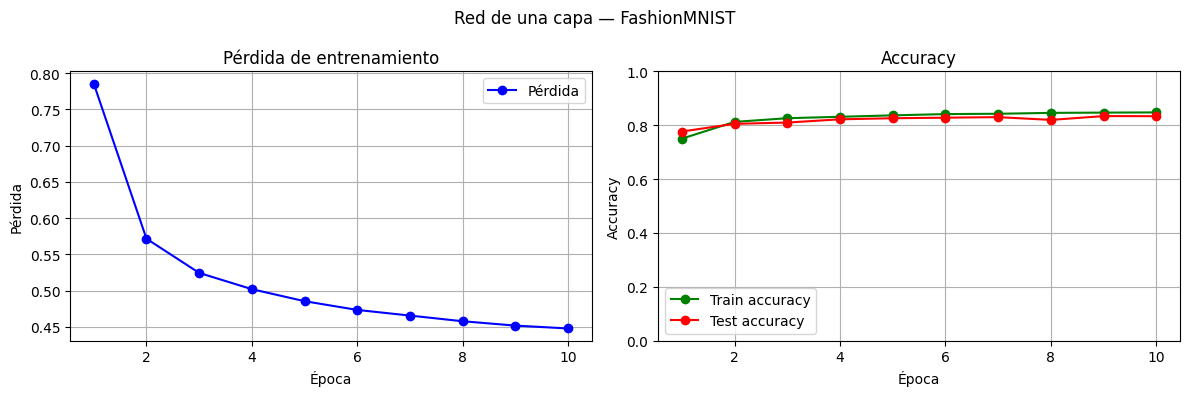

In [28]:
# Cargar dataset con lotes de 256 imágenes
train_iter, test_iter = load_data_fashion_mnist(batch_size=256)

# Entrenar durante 10 épocas
# train() llama internamente a train_epoch() y test_accuracy() en cada época
metrics = train(net, train_iter, test_iter, loss, num_epochs=10, updater=trainer)

# Graficar curvas
plot_metrics(metrics, titulo="Red de una capa — FashionMNIST")


**Pregunta de análisis:**

Observando las curvas:
1. ¿El modelo converge? ¿Cómo se ve eso en el gráfico de pérdida?
2. ¿Hay diferencia entre el train accuracy y el test accuracy? ¿Qué indicaría si esa diferencia fuera muy grande?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

**1. Convergencia:** Sí, el modelo converge. Se puede ver en el gráfico de pérdida: los valores disminuyen con cada época hasta aproximarse a un mínimo. Si la curva se estabiliza (la pendiente se acerca a cero), el modelo llegó a su capacidad máxima con ese lr.

**2. Brecha train vs. test accuracy:** Una pequeña diferencia es normal y esperada; el modelo ve los datos de entrenamiento durante el ajuste de pesos, por lo que aprende a clasificarlos mejor. Si la brecha fuera muy grande (por ejemplo, train acc = 0.99, test acc = 0.60), indicaría **overfitting**: el modelo memorizó los datos de entrenamiento en lugar de aprender patrones generalizables. En este caso, con solo una capa lineal, el modelo es lo suficientemente simple para que el overfitting sea mínimo.

---
## Fin del Laboratorio 1b

Completaste la primera parte del laboratorio de entrenamiento. En el Laboratorio 1c vas a construir un denoising autoencoder.

---
## Notas de corrección

| Ejercicio | Conceptos clave a evaluar | Errores frecuentes |
|---|---|---|
| 1 | Uso correcto de `DataLoader` con `shuffle`. Descargar train y test por separado. | No usar `download=True` o invertir train/test |
| 2 | Arquitectura `Sequential` con `Flatten`. Inicialización de pesos. `CrossEntropyLoss` sin Softmax manual. | Agregar Softmax al modelo (doble aplicación) |
| 3 | Orden correcto: `forward → loss → zero_grad → backward → step`. Acumulación de métricas. | No llamar `zero_grad()` o llamarlo después de `step()` |
| 4 | `argmax(axis=1)` sobre la dimensión de clases. Conversión de tipo antes de comparar. | Usar `axis=0` (sobre el batch) en lugar de `axis=1` |
| 5 | `torch.no_grad()` + `net.eval()`. Diferencia entre modos. | Calcular gradientes en evaluación (desperdicio de recursos) |
| 6 | Llamar a `train_epoch()` y `test_accuracy()` en cada época. Acumular como tuplas. | No guardar métricas o no imprimir el progreso |
| 7 | Uso correcto de `train()` con los componentes del Ej. 2. Interpretar curvas. | No reiniciar el modelo entre experimentos |